In [1]:
import math
import numpy as np
import trajan as ta
import xarray as xr
import parcels
import warnings

from parcels import StatusCode

from operator import attrgetter
from datetime import timedelta
from glob import glob

import matplotlib.pyplot as plt
from IPython.display import HTML
from matplotlib.animation import FuncAnimation

#from parcels import FileWarning

# Add a filter for the xarray decoding warning
#warnings.simplefilter("ignore", FileWarning)

folder = "/srv/seolab/srai/tropicalPacifiTemperatureBudget/WPWP_GLORYS_data/"
ufiles = sorted(glob(f"{folder}/GLORYS12v1_dailyAvg_withVerticalVelocities_2018-0?-??.nc"))

In [2]:
# gridDS = xr.open_dataset(folder + "glorysGrid.nc")
# gridDS = gridDS.rename({'latitude':'gphif',
#                         'longitude':'glamf'})
# firstFile = ufiles[0]
# ds = xr.open_dataset(firstFile)
# gridDS['depthw'] = ds['depth']
# gridDS.to_netcdf(folder + 'coordinates.nc')

In [2]:
# mesh_mask = f"{folder}/coordinates.nc"

# filenames = {
#     "U": {"lon": mesh_mask, "lat": mesh_mask, "depth": mesh_mask, "data": ufiles},
#     "V": {"lon": mesh_mask, "lat": mesh_mask, "depth": mesh_mask, "data": ufiles},
#     "W": {"lon": mesh_mask, "lat": mesh_mask, "depth": mesh_mask, "data": ufiles},
#     # "T": {"lon": mesh_mask, "lat": mesh_mask, "depth": wfiles[0], "data": tfiles},  # Not used in this example
# }

# variables = {
#     "U": "uo",
#     "V": "vo",
#     "W": "wo",
#     # "T": "thetao",  # Not used in this example
# }

# # Note that all variables need the same dimensions in a C-Grid
# c_grid_dimensions = {
#     "lon": "glamf",
#     "lat": "gphif",
#     "depth": "depthw",
#     "time": "time",
# }
# dimensions = {
#     "U": c_grid_dimensions,
#     "V": c_grid_dimensions,
#     "W": c_grid_dimensions,
#     # "T": c_grid_dimensions,  # Not used in this example
# }

# fieldset = parcels.FieldSet.from_nemo(filenames, 
#                                       variables, 
#                                       dimensions, 
#                                       mesh = 'spherical')

# pset = parcels.ParticleSet.from_line(
#     fieldset=fieldset,
#     pclass=parcels.JITParticle,
#     size=20,
#     start=(170, 0),
#     finish=(190, 0),
#     depth=10.0,
# )

# # xpos = np.linspace(170, 200, 10)
# # ypos = np.linspace(-5, 5, 10)
# # X, Y = np.meshgrid(xpos, ypos)
# # xpos = X.flatten()
# # ypos = Y.flatten()

# # pset = parcels.ParticleSet.from_list(
# #     fieldset=fieldset,  # the fields on which the particles are advected
# #     pclass=parcels.JITParticle,  # the type of particles (JITParticle or ScipyParticle)
# #     lon=list(xpos),  # a vector of release longitudes
# #     lat=list(ypos),  # a vector of release latitudes
# # )

# output_file = pset.ParticleFile(
#     name="test.zarr",  # the file name
#     outputdt=timedelta(hours=6),  # the time step of the outputs
# )

# # --- hoist grid values to constants (accessible in JIT kernels) ---
# topW   = float(fieldset.W.grid.depth[0])           # top valid depth level (≈0.5 m)
# Lmin   = float(fieldset.U.grid.lon[0])             # domain min lon
# Lmax   = float(fieldset.U.grid.lon[-1])            # domain max lon
# Lrange = float(Lmax - Lmin)

# fieldset.add_constant('topW', topW)
# fieldset.add_constant('Lmin', Lmin)
# fieldset.add_constant('Lmax', Lmax)
# fieldset.add_constant('Lrange', Lrange)

# # --- kernels: use constants, not fieldset.*.grid.* ---
# def ClampTopDepth(particle, fieldset, time):
#     if particle.depth < 0.5: #fieldset.topW:
#         particle.depth = fieldset.topW

# def HandleErrors(particle, fieldset, time):
#     # Delete any particle that hit an error (>=50 covers all errors)
#     if particle.state >= StatusCode.Error:          # Error == 50
#         particle.delete()
#         # Optional: special-case surface crossing if you prefer to submerge instead:
#         # if particle.state == StatusCode.ErrorThroughSurface:
#         #     particle.depth = fieldset.topW; return

# kernels = pset.Kernel(parcels.AdvectionRK4_3D) + HandleErrors #ClampTopDepth

# pset.execute(kernels, 
#              runtime=timedelta(days=100), 
#              dt=timedelta(hours=6),
#             output_file=output_file)

<xarray.Dataset> Size: 258kB
Dimensions:     (trajectory: 20, obs: 400)
Coordinates:
  * trajectory  (trajectory) int64 160B 40 41 42 43 44 45 ... 54 55 56 57 58 59
  * obs         (obs) int32 2kB 0 1 2 3 4 5 6 7 ... 393 394 395 396 397 398 399
Data variables:
    lat         (trajectory, obs) float64 64kB dask.array<chunksize=(20, 1), meta=np.ndarray>
    lon         (trajectory, obs) float64 64kB dask.array<chunksize=(20, 1), meta=np.ndarray>
    time        (trajectory, obs) datetime64[ns] 64kB dask.array<chunksize=(20, 1), meta=np.ndarray>
    z           (trajectory, obs) float64 64kB dask.array<chunksize=(20, 1), meta=np.ndarray>
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        JITParticleAdvectionRK4_3DHandleErrors
    parcels_mesh:           spherical
    parcels_version:        3.1.4

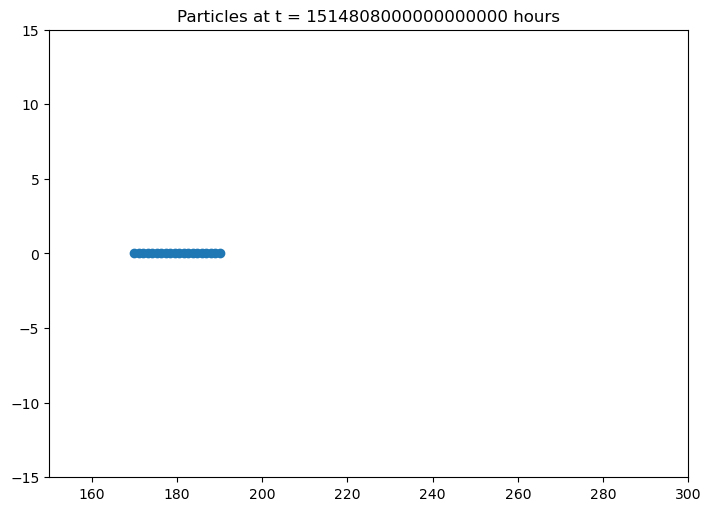

In [4]:
ds = xr.open_zarr("testLine.zarr")

fig = plt.figure(figsize=(7, 5), constrained_layout=True)
ax = fig.add_subplot()

# show only every fifth output (for speed in creating the animation)
timerange = np.unique(ds["time"].values)

# Indices of the data where time = 0
time_id = np.where(ds["time"] == timerange[0])

sc = ax.scatter(ds["lon"].values[time_id], ds["lat"].values[time_id])
ax.set_xlim(150, 300)
ax.set_ylim(-15,15)

t = str(timerange[0].astype("timedelta64[h]"))
title = ax.set_title(f"Particles at t = {t}")

ds

# def animate(i):
#     t = str(timerange[i].astype("timedelta64[h]"))
#     title.set_text(f"Particles at t = {t}")

#     time_id = np.where(ds["time"] == timerange[i])
#     sc.set_offsets(np.c_[ds["lon"].values[time_id], ds["lat"].values[time_id]])


# anim = FuncAnimation(fig, animate, frames=len(timerange), interval=100)

In [12]:
ds

<xarray.Dataset> Size: 258kB
Dimensions:     (trajectory: 20, obs: 400)
Coordinates:
  * trajectory  (trajectory) int64 160B 40 41 42 43 44 45 ... 54 55 56 57 58 59
  * obs         (obs) int32 2kB 0 1 2 3 4 5 6 7 ... 393 394 395 396 397 398 399
Data variables:
    lat         (trajectory, obs) float64 64kB dask.array<chunksize=(20, 1), meta=np.ndarray>
    lon         (trajectory, obs) float64 64kB dask.array<chunksize=(20, 1), meta=np.ndarray>
    time        (trajectory, obs) datetime64[ns] 64kB dask.array<chunksize=(20, 1), meta=np.ndarray>
    z           (trajectory, obs) float64 64kB dask.array<chunksize=(20, 1), meta=np.ndarray>
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        JITParticleAdvectionRK4_3DHandleErrors
    parcels_mesh:           spherical
    parcels_version:        3.1.4

In [7]:
a  =ds.time.to_numpy()

In [11]:
a

array([['2018-01-01T12:00:00.000000000', '2018-01-01T18:00:00.000000000',
        '2018-01-02T00:00:00.000000000', ...,
        '2018-04-10T18:00:00.000000000', '2018-04-11T00:00:00.000000000',
        '2018-04-11T06:00:00.000000000'],
       ['2018-01-01T12:00:00.000000000', '2018-01-01T18:00:00.000000000',
        '2018-01-02T00:00:00.000000000', ...,
        '2018-04-10T18:00:00.000000000', '2018-04-11T00:00:00.000000000',
        '2018-04-11T06:00:00.000000000'],
       ['2018-01-01T12:00:00.000000000', '2018-01-01T18:00:00.000000000',
        '2018-01-02T00:00:00.000000000', ...,
                                  'NaT',                           'NaT',
                                  'NaT'],
       ...,
       ['2018-01-01T12:00:00.000000000', '2018-01-01T18:00:00.000000000',
        '2018-01-02T00:00:00.000000000', ...,
                                  'NaT',                           'NaT',
                                  'NaT'],
       ['2018-01-01T12:00:00.000000000', '20

In [11]:
HTML(anim.to_jshtml())

In [ ]:
import zarr
g = zarr.group()
type(g.store)
#<class 'zarr.storage.DictStore'>

In [ ]:
folder ='/srv/cdx/hseo/Data/GLORYS12v1/PCF/'
ufiles = sorted(glob(f"{folder}/2016/GLORYS12v1_dailyAvg_2016-*.nc"))

for i in range(0, len(ufiles)-1):
    file0 = ufiles[i]
    file1 = ufiles[i+1]
    ds0 = xr.open_dataset(file0)
    ds1 = xr.open_dataset(file1)
    dates = []
    if ds0.time.to_numpy() >= ds1.time.to_numpy():
        print(file1[-13:-3])
        dates.append(file1[-13:-3])
        #print(ds0.time.to_numpy(), ds1.time.to_numpy())

In [ ]:
ufiles

In [ ]:
print(zarr.__version__)

In [ ]:
dir(zarr.storage)

In [ ]:
ds = xr.open_dataset(ufiles[0])

In [ ]:
ds

In [ ]:
xpos = np.linspace(170, 200, 10)
ypos = np.linspace(-5, 5, 10)
X, Y = np.meshgrid(xpos, ypos)
xpos = X.flatten()
ypos = Y.flatten()

In [ ]:
fig, ax = plt.subplots(figsize=(20,8))
ds.thetao.isel(depth=0, time= 0).plot(x = 'longitude', y = 'latitude', ax = ax, vmin = 25, vmax=30, cmap='seismic')
ax.scatter(xpos, ypos)

In [ ]:
v = 1e-3
fig, ax = plt.subplots(figsize=(20,8))
ds.wo.isel(depth=-2, time= 0).plot(x = 'longitude', y = 'latitude', ax = ax, vmin = -v, vmax=v)#, cmap='seismic')
ax.scatter(xpos, ypos)

In [ ]:
np.min(ds.wo), np.max(ds.wo)

In [ ]:
arr = ds.wo.to_numpy().flatten()

In [ ]:
v = 1e-3
plt.hist(arr, bins= np.linspace(-v,v,50))

In [ ]:
1e-4*24*3600